In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, recall_score, precision_score
import time
import warnings
warnings.filterwarnings('ignore')

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

This sounds very similar to the netflix TV show - 'Lost in Space' and I am excited to predict who got transported!

![](https://1721181113.rsc.cdn77.org/data/images/full/26081/suspected-wormholes-can-be-found-says-physicists-who-are-aware-of-these-space-time-anomalies.jpg) 

In [3]:
sns.set_theme(style="ticks")

In [4]:
input_path = Path('/kaggle/input/spaceship-titanic/')
train_data = pd.read_csv(input_path / 'train.csv', index_col='PassengerId')
test_data = pd.read_csv(input_path / 'test.csv', index_col='PassengerId')
submission = pd.read_csv(input_path / 'sample_submission.csv')

## Problem Statement
In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system.

* PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
* HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
* CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
* Destination - The planet the passenger will be debarking to.
* Age - The age of the passenger.
* VIP - Whether the passenger has paid for special VIP service during the voyage.
* RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
* Name - The first and last names of the passenger.
* Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

## Data Exploration

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   object 
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(6)
memory usage: 891.4+ KB


In [6]:
train_data.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Which home planet had the most % of their people transported?

If your home planet was Europa, you are more likely to be transported, followed by Mars and then Earth

Text(0.5, 1.0, 'HomePlanet')

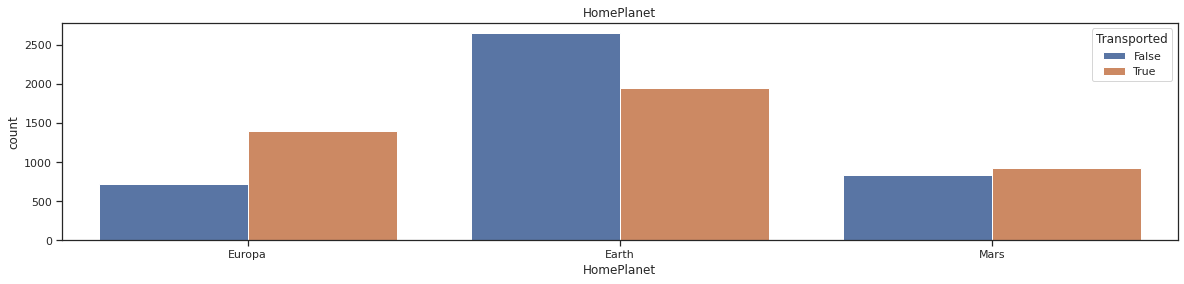

In [7]:
plt.figure(figsize=(20,4))
sns.countplot(data=train_data, x='HomePlanet', hue='Transported')
plt.title('HomePlanet')

Text(0.5, 0, '% transported')

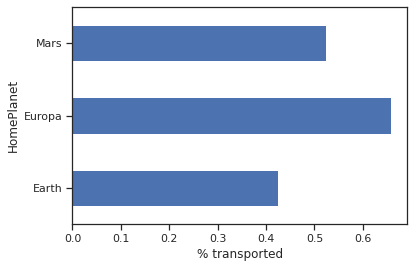

In [8]:
train_data.groupby('HomePlanet').Transported.mean().plot(kind='barh').set_xlabel('% transported')

### Were people more likely to be transported when they are solo or in a group? (Feature engineering also done here to create group size)

If you are in too small or too large group, you are less likely to be transported. If you are in groups of 2-7, more likely to be transported

Text(0.5, 1.0, 'Group size')

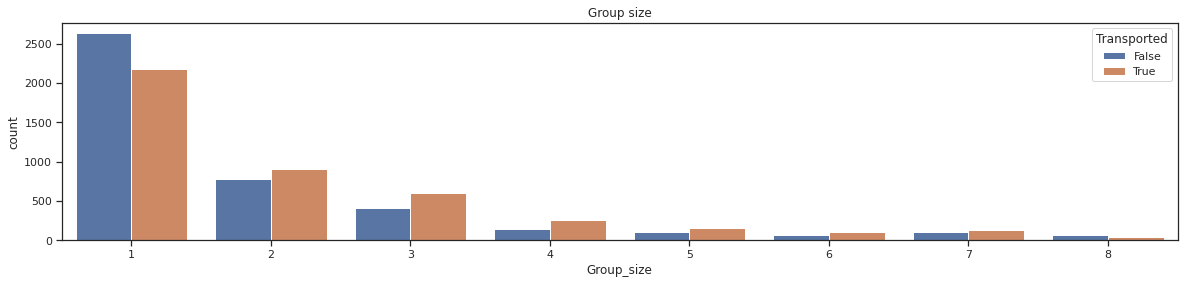

In [9]:
# New feature - Group
train_data['Group'] = [x.split('_')[0] for x in list(train_data.index)]
train_data['Group'] = train_data['Group'].astype(int)
test_data['Group'] = [x.split('_')[0] for x in list(test_data.index)]
test_data['Group'] = test_data['Group'].astype(int)

# New feature - Group size
train_data['Group_size']=train_data['Group'].map(lambda x: train_data['Group'].value_counts()[x])
test_data['Group_size']=test_data['Group'].map(lambda x: test_data['Group'].value_counts()[x])

plt.figure(figsize=(20,4))
sns.countplot(data=train_data, x='Group_size', hue='Transported')
plt.title('Group size')

Text(0.5, 0, '% transported')

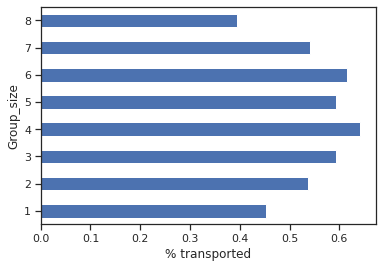

In [10]:
train_data.groupby('Group_size').Transported.mean().plot(kind='barh').set_xlabel('% transported')

### Distribution of expenditure data

<AxesSubplot:>

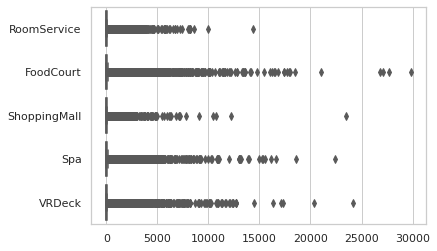

In [11]:
sns.set_theme(style="whitegrid")
expenditure_columns = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
sns.boxplot(data=train_data[expenditure_columns], orient="h", palette="Set2")

## Drop columns that are not helpful

In [12]:
train_data.drop(columns=['Group','Name'],inplace=True)
test_data.drop(columns=['Group','Name'],inplace=True)

## Data cleaning

In [13]:
train_data.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
Group_size        0
dtype: int64

In [14]:
train_data[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']] = train_data[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].fillna(0)

## Feature Engineering

### Let's split the cabin feature into 3 different features - Deck, Number, Side

In [15]:
train_data[['Deck', 'Num', 'Side']] = train_data['Cabin'].str.split('/', expand=True)
test_data[['Deck', 'Num', 'Side']] = test_data['Cabin'].str.split('/', expand=True)

### Let's create a new feature called expenditure which is a sum of all the expenditures

In [16]:
train_data['Expenditure']= train_data[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)
test_data['Expenditure']= test_data[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

<Figure size 72x1080 with 0 Axes>

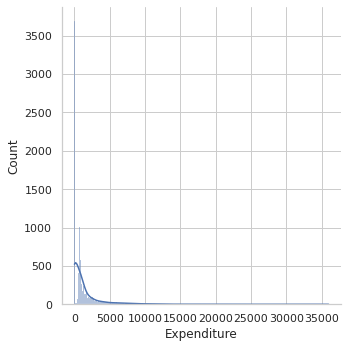

In [17]:
plt.figure(figsize=(1,15))
sns.displot(train_data, x="Expenditure", kde=True)

### Let's create a new feature - whether the person has expenditure or not

In [18]:
train_data['has_expenditure'] = pd.DataFrame(train_data['Expenditure'] > 0).astype(int)
test_data['has_expenditure'] = pd.DataFrame(test_data['Expenditure'] > 0).astype(int)

If the person does not have expenditure, 80% of time, they are transported

Text(0.5, 0, '% transported')

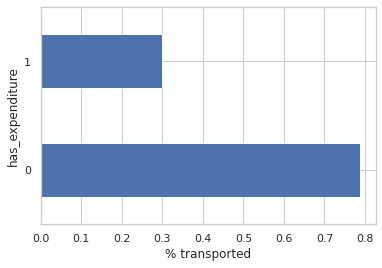

In [19]:
train_data.groupby('has_expenditure').Transported.mean().plot(kind='barh').set_xlabel('% transported')

### Let's log transform the financial features

In [20]:
for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']:
    train_data[col]=np.log(1+train_data[col])
    test_data[col]=np.log(1+test_data[col])

<Figure size 72x1080 with 0 Axes>

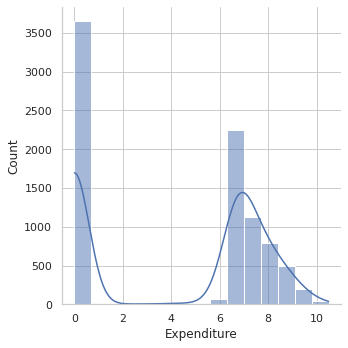

In [21]:
plt.figure(figsize=(1,15))
sns.displot(train_data, x="Expenditure", kde=True)

<AxesSubplot:>

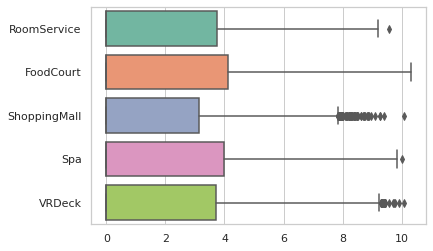

In [22]:
sns.boxplot(data=train_data[expenditure_columns], orient="h", palette="Set2")

### Let's bin the age feature 

In [23]:
test_data["Age"].min(), test_data["Age"].max()
min_age, max_age = train_data["Age"].min(), train_data["Age"].max()
bins = np.linspace(min_age,max_age, 7)
bins
labels = ["0-13 yr olds", "13-26 yr olds", "26-39 year olds", "40-52 yr olds", "53-65 yr olds", "65-79 yr olds"]
train_data["AgeGroup"] = pd.cut(train_data["Age"], bins=bins, labels=labels, include_lowest=True)
test_data["AgeGroup"] = pd.cut(test_data["Age"], bins=bins, labels=labels, include_lowest=True)

## Data Pre-processing using pipelines

In [24]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   HomePlanet       8492 non-null   object  
 1   CryoSleep        8476 non-null   object  
 2   Cabin            8494 non-null   object  
 3   Destination      8511 non-null   object  
 4   Age              8514 non-null   float64 
 5   VIP              8490 non-null   object  
 6   RoomService      8693 non-null   float64 
 7   FoodCourt        8693 non-null   float64 
 8   ShoppingMall     8693 non-null   float64 
 9   Spa              8693 non-null   float64 
 10  VRDeck           8693 non-null   float64 
 11  Transported      8693 non-null   bool    
 12  Group_size       8693 non-null   int64   
 13  Deck             8494 non-null   object  
 14  Num              8494 non-null   object  
 15  Side             8494 non-null   object  
 16  Expenditure      8693 non-null   float

In [25]:
categorical_cols = [col for col in train_data.columns if train_data[col].dtype in ["object","category"]]
numerical_cols = [col for col in train_data.columns if train_data[col].dtype in ["float64",'int64']]

In [26]:
# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
]) 

def to_int(x):
    return pd.DataFrame(x).astype(int)


# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False,handle_unknown='ignore'))
])

# Preprocessing for ordinal data
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('toint', FunctionTransformer(to_int)),
    ('label', LabelEncoder())
])


# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        #('ord', ordinal_transformer, ordinal_cols)
    ])


## BaseLine Model - Random Forest using pipelines

Performance on test data - 0.79~

In [27]:
X = train_data.copy()
y = X.pop('Transported')
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=1)

In [28]:
model = RandomForestClassifier(n_estimators=100, random_state=0)

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

# # Preprocessing of training data, fit model 
rf_pipeline.fit(X_train, y_train)

# # Preprocessing of validation data, get predictions
preds = rf_pipeline.predict(X_valid)

# # Evaluate the model
score = accuracy_score(y_valid, preds)
print('validation_accuracy_score:', score)

validation_accuracy_score: 0.7897884084636615


In [29]:
print('CV Score:', cross_val_score(rf_pipeline, X, y,cv=3,scoring='accuracy').mean())

CV Score: 0.7799398868871036


## Model Explainability

In [30]:
onehot_columns = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names(input_features=categorical_cols)
#ordinal_columns = rf_pipeline.named_steps['preprocessor'].named_transformers_['ord'].named_steps['ordinal'].get_feature_names(input_features=ordinal_cols)
transformed_features_list = list(numerical_cols) 
transformed_features_list.extend(onehot_columns)
#transformed_features_list.extend(ordinal_columns)

In [31]:
import eli5
eli5.explain_weights(rf_pipeline.named_steps['model'], top=50, feature_names=transformed_features_list, feature_filter=lambda x: x != '<BIAS>')

Weight,Feature
0.0593 ± 0.1197,Expenditure
0.0515 ± 0.1447,CryoSleep_True
0.0452 ± 0.1278,has_expenditure
0.0417 ± 0.0620,VRDeck
0.0414 ± 0.0514,Spa
0.0396 ± 0.0154,Age
0.0387 ± 0.0352,FoodCourt
0.0340 ± 0.0566,RoomService
0.0326 ± 0.0383,ShoppingMall
0.0285 ± 0.0930,CryoSleep_False


In [32]:
# import shap  # package used to calculate Shap values
# shap.initjs() 
# # Create object that can calculate shap values
# explainer = shap.TreeExplainer(my_pipeline.named_steps['model'])
# observations = my_pipeline.named_steps["preprocessor"].transform(X_valid[0])
# shap_values = explainer.shap_values(observations)
# i = 0
# shap.force_plot(explainer.expected_value, shap_values[i], 
#                  features=observations[i], feature_names=transformed_features_list)

## Model HorseRace - Using Grid Search 

Acknowledgement : https://www.kaggle.com/code/jiwonkng/spaceship-titanic-eda-preprocessing-modeling

In [33]:
# X = train_data.copy()
# y = X.pop('Transported')

# X_transformed = preprocessor.fit_transform(X)
# test_data_transformed = preprocessor.transform(test_data)

# X_train, X_valid, y_train, y_valid = train_test_split(X_transformed, y, random_state=1)

# hyerparameters grid to search within
# param_grid = [
#     {'model__bootstrap': [False, True],
#      'model__n_estimators': [100,200],
#       'model__max_features': [0.6, 0.7,  0.8],
#       'model__min_samples_leaf': [10, 15],
#       'model__min_samples_split': [3, 5, 7]
#     },
# ]

# # define grid
# KNN_grid = {'n_neighbors': [3],
#             'p': [1]}

# LR_grid = {
#            'C': [0.25, 0.5],
#            'max_iter': [50, 100]}

# RF_grid = {'n_estimators': [100],
#         'max_depth': [5]}

# LGBM_grid = {'n_estimators': [100, 200],
#         'max_depth': [4, 8],
#         'learning_rate': [0.05]}

# grid = {
#     "KNN" : KNN_grid,
#     "LogisticRegression" : LR_grid,
#     "RandomForest" : RF_grid,
#     "LGBM" : LGBM_grid
# }

# classifiers = {
#     "KNN" : KNeighborsClassifier(),
#     "LogisticRegression" : LogisticRegression(random_state=42),
#     "RandomForest" : RandomForestClassifier(random_state=42),
#     "LGBM" : LGBMClassifier(random_state=42)
# }
# clf_best_params = classifiers.copy()
# scores = pd.DataFrame({
#                     'Classifer':classifiers.keys(),
#                     'Train accuracy' : np.zeros(len(classifiers)),
#                     'Validation accuracy': np.zeros(len(classifiers)),
#                     'Training time': np.zeros(len(classifiers))
#                     })

# i = 0
# for key, classifier in classifiers.items():
#     # Bundle preprocessing and modeling code in a pipeline
#     start = time.time()
#     clf = GridSearchCV(classifier, param_grid=grid[key], cv=None,scoring='accuracy')
#     clf.fit(X_train, y_train)
#     scores.iloc[i,1]=clf.score(X_train, y_train)
#     scores.iloc[i,2]=clf.score(X_valid, y_valid)
#     clf_best_params[key]=clf.best_params_
#     stop = time.time()
#     scores.iloc[i,3]=np.round((stop - start)/60, 2)
#     i += 1
# clf_best_params

Looks like Light GBM is the best model based on validation accuracy

## Model using Light GBM 

Performance on test data - 0.80~

In [34]:
X = train_data.copy()
y = X.pop('Transported')
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=1)

In [35]:
model = LGBMClassifier(n_estimators=500, 
                       #colsample_bytree = 0.7, max_depth= 5, learning_rate= 0.1,
                       random_state=42)
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

# # Preprocessing of training data, fit model 
lgbm_pipeline.fit(X_train, y_train)

# # Preprocessing of validation data, get predictions
preds = lgbm_pipeline.predict(X_valid)

# # Evaluate the model
score = accuracy_score(y_valid, preds)
print('accuracy_score:', score)

accuracy_score: 0.7943882244710212


In [36]:
print('CV Score:', cross_val_score(lgbm_pipeline, X, y,cv=3,scoring='accuracy').mean())

CV Score: 0.7909825804424414


## Model using XGBoost using GridSearch CV

https://mlfromscratch.com/gridsearch-keras-sklearn/#/

In [37]:
# X = train_data.copy()
# y = X.pop('Transported')

# X_transformed = preprocessor.fit_transform(X)
# test_data_transformed = preprocessor.transform(test_data)

# model = XGBClassifier(tree_method='gpu_hist', predictor="gpu_predictor")
# param_grid = {
#     'n_estimators': [100, 200, 500], #100
#     'colsample_bytree': [0.7, 0.8], #0.7
#     'max_depth': [5,10], #5
#     'learning_rate': [0.1,0.01],
# }
# gs = GridSearchCV(
#         estimator=model,
#         param_grid=param_grid, 
#         cv=3, 
#         n_jobs=-1, 
#         scoring='accuracy',
#         verbose=10
#     )
# # # Preprocessing of training data, fit model 
# gs.fit(X_transformed, y)
# gs.score(X_transformed, y)
# gs.best_params_

## Model using XGBoost through above grid-searched params

Performance on test data - 0.80~ , not that much improvement over LightGBM

In [38]:
X = train_data.copy()
y = X.pop('Transported')
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=1)

In [39]:
model = XGBClassifier(n_estimators=100, colsample_bytree = 0.7, max_depth= 5, learning_rate= 0.1
                      #,tree_method='gpu_hist', predictor="gpu_predictor"
                     )
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

# # Preprocessing of training data, fit model 
xgb_pipeline.fit(X_train, y_train)

# # Preprocessing of validation data, get predictions
preds = xgb_pipeline.predict(X_valid)

# # Evaluate the model
score = accuracy_score(y_valid, preds)
print('accuracy_score:', score)

accuracy_score: 0.8192272309107635


In [40]:
print('CV Score:', cross_val_score(xgb_pipeline, X, y,cv=3,scoring='accuracy').mean())

CV Score: 0.7986896402273628


## Model using Tensorflow Keras

https://www.tensorflow.org/tutorials/structured_data/preprocessing_layers

Performance on test - 0.7803 

In [41]:
X = train_data.copy()
y = X.pop('Transported')
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=1)

In [42]:
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

In [43]:
input_shape = [X_train.shape[1]]

In [44]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

2022-07-01 07:54:27.846182: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-01 07:54:27.851263: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-01 07:54:27.852084: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-01 07:54:27.853869: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

2022-07-01 07:54:34.274736: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/200
13/13 [==============================] - 3s 46ms/step - loss: 0.7597 - binary_accuracy: 0.6231 - val_loss: 0.6354 - val_binary_accuracy: 0.7323
Epoch 2/200
13/13 [==============================] - 0s 17ms/step - loss: 0.3790 - binary_accuracy: 0.8311 - val_loss: 0.6143 - val_binary_accuracy: 0.7139
Epoch 3/200
13/13 [==============================] - 0s 16ms/step - loss: 0.2222 - binary_accuracy: 0.9093 - val_loss: 0.6041 - val_binary_accuracy: 0.6481
Epoch 4/200
13/13 [==============================] - 0s 16ms/step - loss: 0.1385 - binary_accuracy: 0.9480 - val_loss: 0.5914 - val_binary_accuracy: 0.6711
Epoch 5/200
13/13 [==============================] - 0s 17ms/step - loss: 0.1064 - binary_accuracy: 0.9587 - val_loss: 0.5754 - val_binary_accuracy: 0.6826
Epoch 6/200
13/13 [==============================] - 0s 16ms/step - loss: 0.0992 - binary_accuracy: 0.9587 - val_loss: 0.5603 - val_binary_accuracy: 0.7042
Epoch 7/200
13/13 [==============================] - 0s 16ms/ste

<AxesSubplot:title={'center':'Accuracy'}>

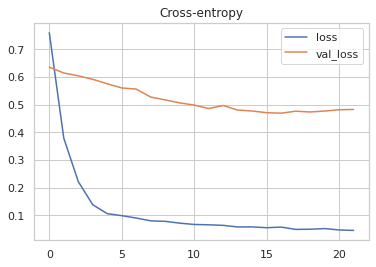

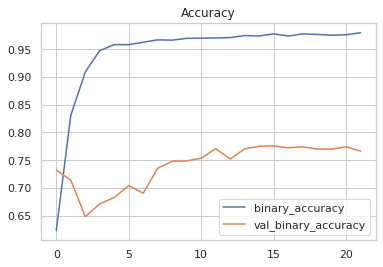

In [45]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Accuracy")

## Predict using test data

In [46]:
#If choosing NN
# X_test = preprocessor.transform(test_data)
# probs_test = model.predict(X_test)
# preds_test = [True if x > 0.5 else False for x in probs_test]
# submission['Transported'] = preds_test

In [47]:
#If choosing other models
preds_test = lgbm_pipeline.predict(test_data) 
submission['Transported'] = preds_test.astype(bool)

## Submission as CSV

In [48]:
submission.to_csv('submission.csv', index = False)